# Augmentations-4: Results / Tests on Data Part 1 - Aug

In [1]:
import os
import sys
import time
from pathlib import Path

root = Path.cwd()
print(root)
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

_ipynb = Path.cwd() / "ipynb"
if str(_ipynb) not in sys.path:
    sys.path.insert(0, str(_ipynb))

from view_augments.metric_review import (
    get_metric_paths,
    mip_biapy_gt_instance,
    plot_image_grid,

    _load_volume,
    mip_biapy_gt_instance,
)


/scratch/wmz2007/neuroinfo_fruitfly/ipynb
/scratch/wmz2007/neuroinfo_fruitfly


## Viewing Results

### Segmentation Prediction

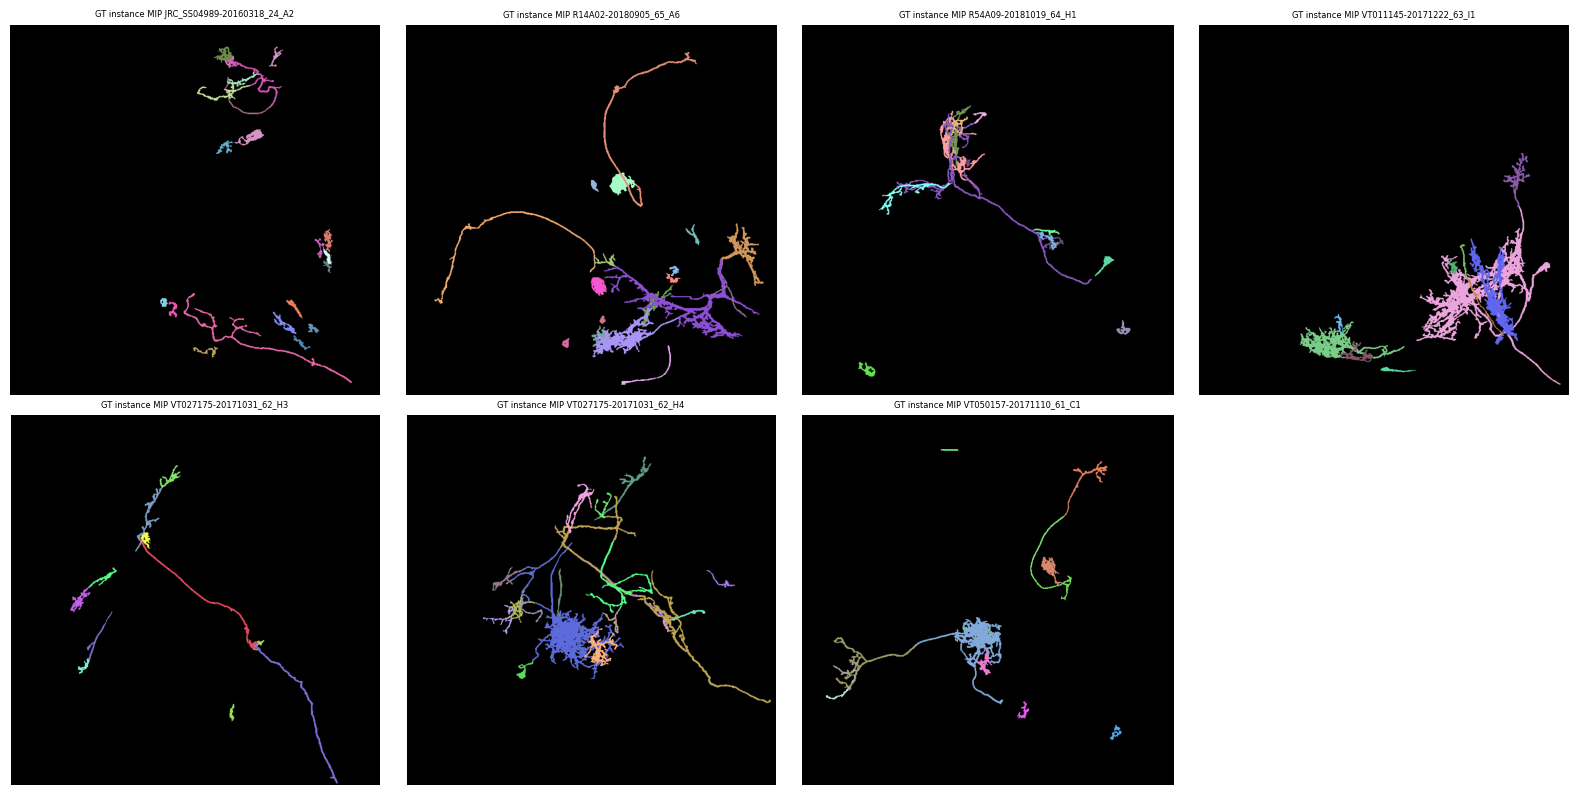

(<Figure size 1600x800 with 8 Axes>,
 array([[<Axes: title={'center': 'GT instance MIP JRC_SS04989-20160318_24_A2'}>,
         <Axes: title={'center': 'GT instance MIP R14A02-20180905_65_A6'}>,
         <Axes: title={'center': 'GT instance MIP R54A09-20181019_64_H1'}>,
         <Axes: title={'center': 'GT instance MIP VT011145-20171222_63_I1'}>],
        [<Axes: title={'center': 'GT instance MIP VT027175-20171031_62_H3'}>,
         <Axes: title={'center': 'GT instance MIP VT027175-20171031_62_H4'}>,
         <Axes: title={'center': 'GT instance MIP VT050157-20171110_61_C1'}>,
         <Axes: >]], dtype=object))

In [2]:
CONFIG = "biapy-channel-scale-zarr-seunet"
RUN = "1_w3443"

plot_image_grid(get_metric_paths('per_image_post_processing', CONFIG, RUN), mip_biapy_gt_instance, ncols=4, figsize_cell=(4, 4), font_siz=6)

### Merging Research

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import relabel_sequential


In [4]:
CONFIG = "biapy-channel-scale-zarr-seunet"
RUN = "1_w3443"

samples_paths = get_metric_paths('per_image_post_processing', CONFIG, RUN)
for i in samples_paths: print(i)
sample_path = samples_paths[1]
sample_path


metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/JRC_SS04989-20160318_24_A2.tif
metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/R14A02-20180905_65_A6.tif
metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/R54A09-20181019_64_H1.tif
metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/VT011145-20171222_63_I1.tif
metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/VT027175-20171031_62_H3.tif
metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/VT027175-20171031_62_H4.tif
metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_proc

PosixPath('metrics/biapy/biapy-channel-scale-zarr-seunet/results/biapy-channel-scale-zarr-seunet_1_w3443/per_image_post_processing/R14A02-20180905_65_A6.tif')

In [5]:
sample_data = _load_volume(sample_path)
sample_data.shape, np.unique(sample_data)

((385, 685, 686),
 array([   0.,    7.,   88.,  121.,  279.,  284.,  325.,  337., 1309.,
        1326., 1617., 2016., 2872., 4360., 4544., 5438., 5521., 5591.,
        6155.], dtype=float32))

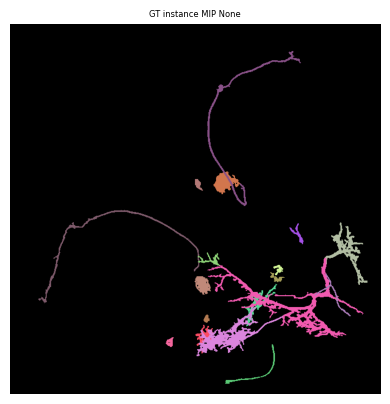

In [6]:
fig, ax = plt.subplots(1, 1)
mip_biapy_gt_instance(ax, sample_data, 'None')

### Merging algorithm

Watershed and other post-processing steps can split a single neuron into multiple instance IDs when the fragments share a boundary voxel (face, edge, or corner contact).

**Approach:** Treat each non-zero label as a node in a graph. Add an edge when two labels are neighbors under the chosen connectivity (6 or 26). Each connected component of that graph becomes one merged instance.

**Why union-find:** Boundary scanning only sees direct touching pairs, but merges must be transitive (A touches B, B touches C → all become one). Union-find collects those chains efficiently in one pass.

**Connectivity:**
- `6` — face-adjacent only (stricter; fewer merges)
- `26` — face, edge, or corner adjacent (more aggressive; demo run below: 18 → 12 instances)

**Half-neighborhood:** `_touching_offsets` returns only offsets in one lexicographic half-space (e.g. `(dz, dy, dx) > (0, 0, 0)`), so each voxel pair is checked once instead of twice.

In [7]:
def _touching_offsets(connectivity=26):
    """Return neighbor offset vectors for boundary scanning.

    Each offset (dz, dy, dx) shifts one sub-volume relative to another so we
    can compare labels at adjacent voxels. Only half the neighborhood is
    returned so each voxel pair is examined once.

    Args:
        connectivity: 6 (face neighbors only) or 26 (face/edge/corner).

    Returns:
        List of (dz, dy, dx) tuples. For connectivity 6 this is the three
        positive axis directions; for 26 it is all non-zero offsets in the
        lexicographic half-space where (dz, dy, dx) > (0, 0, 0).
    """
    if connectivity == 6:
        # Face neighbors along +Z, +Y, +X only (negative dirs covered by pair symmetry).
        return [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
    if connectivity == 26:
        offs = []
        for dz in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if (dz, dy, dx) == (0, 0, 0):
                        continue
                    if (dz, dy, dx) > (0, 0, 0):  # lexicographic half-space
                        offs.append((dz, dy, dx))
        return offs
    raise ValueError("connectivity must be 6 or 26")


def merge_touching_labels(labels, connectivity=26):
    """Merge instance IDs that share a 6- or 26-connected boundary voxel.

    Builds a graph of touching labels and unions connected components via
    union-find. Only directly adjacent foreground labels merge; labels
    separated by background are never joined.

    Args:
        labels: 3D label array (0 = background, positive ints = instances).
        connectivity: 6 or 26 neighbor definition for "touching".

    Returns:
        Relabeled 3D array with contiguous instance IDs (1..N) via
        ``relabel_sequential``; background stays 0.

    Side effects:
        Prints instance count before and after merging.
    """
    labels = np.asarray(labels)
    labels = np.squeeze(labels)
    if labels.ndim != 3:
        raise ValueError(f"expected 3D labels after squeeze, got shape {labels.shape}")

    labels = labels.astype(np.int32, copy=False)
    ids = np.unique(labels)
    ids = ids[ids != 0]
    n_before = len(ids)

    # Union-find: each label starts as its own set.
    parent = {int(i): int(i) for i in ids}

    def find(x):
        # Path compression: flatten parent chain on lookup.
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra  # attach one root under the other

    for dz, dy, dx in _touching_offsets(connectivity):
        # Vectorized neighbor check: aligned sub-volumes separated by offset.
        a = labels[max(dz, 0) : labels.shape[0] + min(dz, 0),
                   max(dy, 0) : labels.shape[1] + min(dy, 0),
                   max(dx, 0) : labels.shape[2] + min(dx, 0)]
        b = labels[max(-dz, 0) : labels.shape[0] + min(-dz, 0),
                   max(-dy, 0) : labels.shape[1] + min(-dy, 0),
                   max(-dx, 0) : labels.shape[2] + min(-dx, 0)]
        # Only merge foreground labels that differ at the boundary.
        mask = (a != 0) & (b != 0) & (a != b)
        if not np.any(mask):
            continue
        # Deduplicate boundary pairs before union calls.
        pairs = np.unique(np.stack([a[mask], b[mask]], axis=1), axis=0)
        for ia, ib in pairs:
            union(int(ia), int(ib))

    # Remap every voxel to its component root label.
    out = np.zeros_like(labels)
    for i in ids:
        out[labels == i] = find(int(i))

    # Compact IDs to 1..N for downstream metrics/plots.
    out, _, _ = relabel_sequential(out)
    n_after = len(np.unique(out)) - (1 if 0 in out else 0)
    print(f"instances: {n_before} -> {n_after} (connectivity={connectivity})")
    return out


In [8]:
# connectivity=26 merges fragments that touch at faces, edges, or corners.
merged = merge_touching_labels(sample_data, connectivity=26)
merged.shape, np.unique(merged)


instances: 18 -> 12 (connectivity=26)


((385, 685, 686),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32))

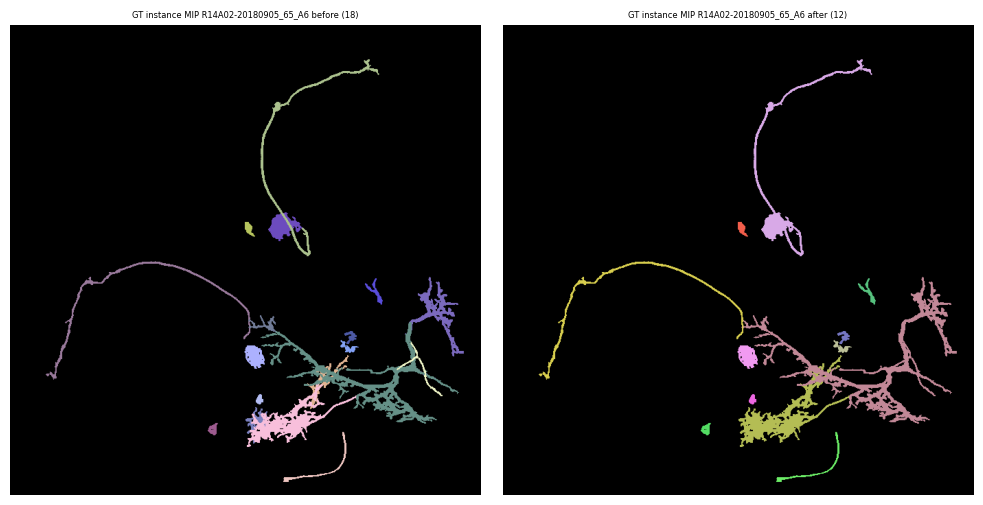

In [9]:
# Count foreground instances only (exclude background label 0).
n_before = int(np.unique(sample_data).size) - int(np.any(sample_data == 0))
n_after = int(np.unique(merged).size) - int(np.any(merged == 0))
stem = sample_path.stem

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mip_biapy_gt_instance(axes[0], sample_data, f"{stem} before ({n_before})")
mip_biapy_gt_instance(axes[1], merged, f"{stem} after ({n_after})")
plt.tight_layout()
plt.show()
